In [33]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("Random seed set to 42")

PyTorch version: 2.13.0+cpu
Random seed set to 42


In [34]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

In [35]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [36]:
import os

print("Files in Day 11:")
print(os.listdir("../Day 11"))

Files in Day 11:
['deep_learning_baseline.ipynb', 'Loan_default.csv', 'README.md', 'requirements.txt']


In [37]:
df = pd.read_csv("../Day 11/Loan_default.csv")

In [38]:
print("Target column values:")
print(df["Default"].value_counts())

print("\nTarget data type:")
print(df["Default"].dtype)

Target column values:
Default
0    225694
1     29653
Name: count, dtype: int64

Target data type:
int64


In [39]:
X = df.drop(columns=["Default"])
y = df["Default"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (255347, 17)
y shape: (255347,)


In [40]:
if "LoanID" in X.columns:
    X = X.drop(columns=["LoanID"])

print("X shape after removing LoanID:", X.shape)

X shape after removing LoanID: (255347, 16)


In [41]:
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)
print("\nData types:")
print(X.dtypes.value_counts())

X shape after encoding: (255347, 24)

Data types:
bool       15
int64       7
float64     2
Name: count, dtype: int64


In [42]:
X = X.astype(np.float32)

print("X data type:", X.dtypes.unique())
print("X shape:", X.shape)

X data type: [dtype('float32')]
X shape: (255347, 24)


In [43]:
print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [44]:
X = X.fillna(X.median(numeric_only=True))


In [45]:
print("Missing values after cleaning:", X.isnull().sum().sum())

Missing values after cleaning: 0


In [46]:
y = y.astype(int)

print("Target classes:", sorted(y.unique()))
print("Target distribution:")
print(y.value_counts())

Target classes: [np.int64(0), np.int64(1)]
Target distribution:
Default
0    225694
1     29653
Name: count, dtype: int64


In [47]:
indices = np.arange(len(X))

np.random.seed(SEED)
np.random.shuffle(indices)

split_index = int(0.80 * len(indices))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (204277, 24)
X_test : (51070, 24)
y_train: (204277,)
y_test : (51070,)


In [48]:
train_mean = X_train.mean()
train_std = X_train.std()

train_std = train_std.replace(0, 1)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("Feature scaling completed!")

Feature scaling completed!


In [49]:
X_train_tensor = torch.tensor(
    X_train.values.copy(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test.values.copy(),
    dtype=torch.float32
)

print("X_train tensor:", X_train_tensor.shape)
print("X_test tensor :", X_test_tensor.shape)
print("X tensor dtype:", X_train_tensor.dtype)

X_train tensor: torch.Size([204277, 24])
X_test tensor : torch.Size([51070, 24])
X tensor dtype: torch.float32


In [50]:
y_train_tensor = torch.tensor(
    y_train.values.copy(),
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test.values.copy(),
    dtype=torch.long
)

print("y_train tensor:", y_train_tensor.shape)
print("y_test tensor :", y_test_tensor.shape)
print("y tensor dtype:", y_train_tensor.dtype)

y_train tensor: torch.Size([204277])
y_test tensor : torch.Size([51070])
y tensor dtype: torch.int64


In [51]:
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_test :", X_test_tensor.shape)
print("y_test :", y_test_tensor.shape)

X_train: torch.Size([204277, 24])
y_train: torch.Size([204277])
X_test : torch.Size([51070, 24])
y_test : torch.Size([51070])


In [52]:
input_size = X_train_tensor.shape[1]
output_size = len(torch.unique(y_train_tensor))

print("Input size:", input_size)
print("Output size:", output_size)

Input size: 24
Output size: 2


In [53]:
class LoanDefaultMLP(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_layer = nn.Linear(input_size, 64)

        self.hidden_layer = nn.Linear(64, 32)

        self.relu = nn.ReLU()

        self.output_layer = nn.Linear(32, output_size)

    def forward(self, x):

        x = self.input_layer(x)

        x = self.relu(x)

        x = self.hidden_layer(x)

        x = self.relu(x)

        x = self.output_layer(x)

        return x


model = LoanDefaultMLP(
    input_size,
    output_size
)

print(model)

LoanDefaultMLP(
  (input_layer): Linear(in_features=24, out_features=64, bias=True)
  (hidden_layer): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)


### ReLU Activation

ReLU (Rectified Linear Unit) is defined as:

f(x) = max(0, x)

For positive values, ReLU returns x, while for negative values it returns 0.

ReLU introduces non-linearity into the neural network and helps reduce the vanishing-gradient problem compared with sigmoid activations in deep networks because its derivative is 1 for positive inputs.

In [54]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [55]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [56]:
epochs = 20

loss_history = []

for epoch in range(epochs):

    # Clear previous gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_tensor)

    # Calculate loss
    loss = criterion(
        outputs,
        y_train_tensor
    )

    # Backpropagation
    loss.backward()

    # Update model weights
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {loss.item():.4f}"
    )

Epoch [1/20] Loss: 0.7557
Epoch [2/20] Loss: 0.7387
Epoch [3/20] Loss: 0.7225
Epoch [4/20] Loss: 0.7069
Epoch [5/20] Loss: 0.6921
Epoch [6/20] Loss: 0.6778
Epoch [7/20] Loss: 0.6641
Epoch [8/20] Loss: 0.6508
Epoch [9/20] Loss: 0.6378
Epoch [10/20] Loss: 0.6253
Epoch [11/20] Loss: 0.6130
Epoch [12/20] Loss: 0.6009
Epoch [13/20] Loss: 0.5891
Epoch [14/20] Loss: 0.5774
Epoch [15/20] Loss: 0.5659
Epoch [16/20] Loss: 0.5546
Epoch [17/20] Loss: 0.5435
Epoch [18/20] Loss: 0.5325
Epoch [19/20] Loss: 0.5217
Epoch [20/20] Loss: 0.5111


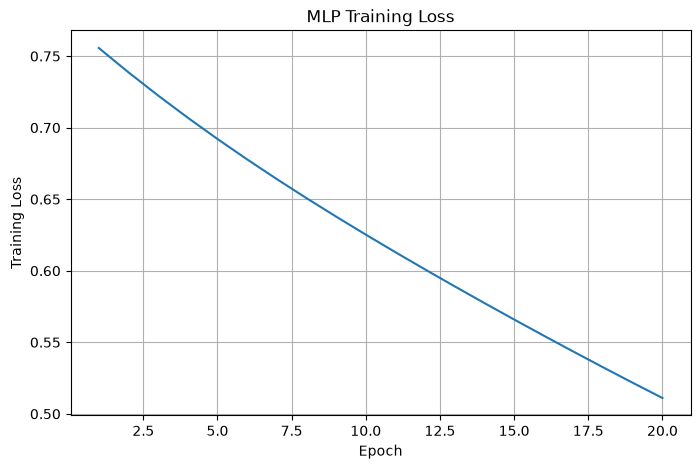

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Training Loss")

plt.grid(True)
plt.show()

In [58]:
model.eval()

with torch.no_grad():

    test_outputs = model(X_test_tensor)

    predictions = torch.argmax(
        test_outputs,
        dim=1
    )

accuracy = (
    predictions == y_test_tensor
).float().mean()

print(
    f"Test Accuracy: {accuracy.item() * 100:.2f}%"
)

Test Accuracy: 88.57%


In [59]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 204277
Validation dataset size: 51070


In [60]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 3192
Validation batches: 798


In [61]:
X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)
print("X dtype:", X_batch.dtype)
print("y dtype:", y_batch.dtype)

X batch shape: torch.Size([64, 24])
y batch shape: torch.Size([64])
X dtype: torch.float32
y dtype: torch.int64


In [62]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Adam optimizer ready")

Adam optimizer ready


In [63]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [64]:
train_losses = []
val_losses = []

num_epochs = 25

for epoch in range(num_epochs):

    # Training
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)

    # Validation
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

Epoch [1/25] Train Loss: 0.3197 Val Loss: 0.3143
Epoch [2/25] Train Loss: 0.3147 Val Loss: 0.3129
Epoch [3/25] Train Loss: 0.3134 Val Loss: 0.3137
Epoch [4/25] Train Loss: 0.3129 Val Loss: 0.3118
Epoch [5/25] Train Loss: 0.3123 Val Loss: 0.3119
Epoch [6/25] Train Loss: 0.3118 Val Loss: 0.3123
Epoch [7/25] Train Loss: 0.3113 Val Loss: 0.3127
Epoch [8/25] Train Loss: 0.3110 Val Loss: 0.3129
Epoch [9/25] Train Loss: 0.3106 Val Loss: 0.3130
Epoch [10/25] Train Loss: 0.3103 Val Loss: 0.3136
Epoch [11/25] Train Loss: 0.3097 Val Loss: 0.3129
Epoch [12/25] Train Loss: 0.3094 Val Loss: 0.3138
Epoch [13/25] Train Loss: 0.3090 Val Loss: 0.3153
Epoch [14/25] Train Loss: 0.3087 Val Loss: 0.3144
Epoch [15/25] Train Loss: 0.3083 Val Loss: 0.3141
Epoch [16/25] Train Loss: 0.3079 Val Loss: 0.3141
Epoch [17/25] Train Loss: 0.3078 Val Loss: 0.3150
Epoch [18/25] Train Loss: 0.3074 Val Loss: 0.3151
Epoch [19/25] Train Loss: 0.3070 Val Loss: 0.3156
Epoch [20/25] Train Loss: 0.3066 Val Loss: 0.3149
Epoch [21

In [65]:
print("Number of training loss values:", len(train_losses))
print("Number of validation loss values:", len(val_losses))

print("Final Training Loss:", train_losses[-1])
print("Final Validation Loss:", val_losses[-1])

Number of training loss values: 25
Number of validation loss values: 25
Final Training Loss: 0.3053639659046529
Final Validation Loss: 0.3170591262087487


In [66]:
best_val_loss = min(val_losses)
best_epoch = val_losses.index(best_val_loss) + 1

print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Epoch: {best_epoch}")

Best Validation Loss: 0.3118
Best Epoch: 4


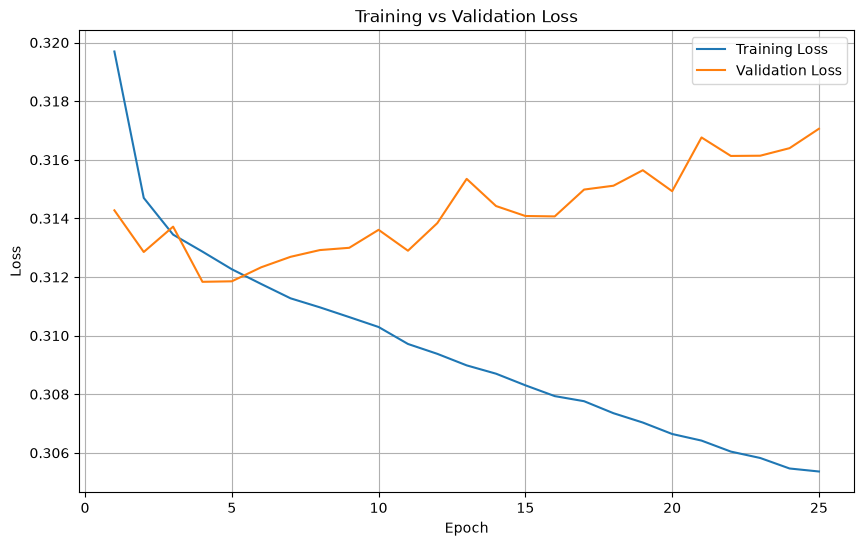

In [67]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [68]:
print("========== DAY 12 FINAL CHECK ==========")
print("Batch size: 64")
print("Training shuffle: True")
print("Validation shuffle: False")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Epochs:", len(train_losses))
print("Training loss points:", len(train_losses))
print("Validation loss points:", len(val_losses))
print("Best validation loss:", best_val_loss)
print("Best epoch:", best_epoch)

========== DAY 12 FINAL CHECK ==========
Batch size: 64
Training shuffle: True
Validation shuffle: False
Optimizer: Adam
Learning rate: 0.001
Epochs: 25
Training loss points: 25
Validation loss points: 25
Best validation loss: 0.31183627004125963
Best epoch: 4


In [69]:
print("========== TRAINING SUMMARY ==========")
print(f"Initial Training Loss: {train_losses[0]:.4f}")
print(f"Final Training Loss:   {train_losses[-1]:.4f}")
print(f"Initial Validation Loss: {val_losses[0]:.4f}")
print(f"Final Validation Loss:   {val_losses[-1]:.4f}")
print(f"Best Validation Loss:    {best_val_loss:.4f}")
print(f"Best Epoch:              {best_epoch}")

========== TRAINING SUMMARY ==========
Initial Training Loss: 0.3197
Final Training Loss:   0.3054
Initial Validation Loss: 0.3143
Final Validation Loss:   0.3171
Best Validation Loss:    0.3118
Best Epoch:              4


# Day 13 — Neural Network Regularization, Dropout & Batch Normalization

## Objective

Upgrade the Day 12 baseline MLP by introducing Batch Normalization and Dropout. The baseline and regularized models will be trained for 30 epochs using Adam and compared using training and validation loss curves.

## Day 13 Requirements

Today's implementation includes:

- Reusing the Day 12 `train_loader` and `val_loader`
- Building a baseline MLP
- Building a RegularizedMLP using `BatchNorm1d`
- Adding `Dropout(p=0.3)`
- Training both models for 30 epochs
- Using the Adam optimizer
- Using `model.train()` during training
- Using `model.eval()` and `torch.no_grad()` during validation
- Tracking training and validation loss
- Comparing the two models using 2×1 Matplotlib loss curves
- Analyzing overfitting and generalization

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)
print("PyTorch version:", torch.__version__)

Random seed: 42
PyTorch version: 2.13.0+cpu


In [71]:
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)
print("X dtype:", X_batch.dtype)
print("y dtype:", y_batch.dtype)

Training batches: 3192
Validation batches: 798
X batch shape: torch.Size([64, 24])
y batch shape: torch.Size([64])
X dtype: torch.float32
y dtype: torch.int64


In [72]:
input_size = X_train_tensor.shape[1]
output_size = len(torch.unique(y_train_tensor))

print("Input size:", input_size)
print("Output size:", output_size)



Input size: 24
Output size: 2


In [73]:
class BaselineMLP(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_layer = nn.Linear(input_size, 64)
        self.hidden_layer = nn.Linear(64, 32)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(32, output_size)

    def forward(self, x):

        x = self.input_layer(x)
        x = self.relu(x)

        x = self.hidden_layer(x)
        x = self.relu(x)

        x = self.output_layer(x)

        return x

In [74]:
class RegularizedMLP(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_layer = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.3)

        self.hidden_layer = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.3)

        self.output_layer = nn.Linear(32, output_size)

    def forward(self, x):

        x = self.input_layer(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.hidden_layer(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.output_layer(x)

        return x

In [75]:
class RegularizedMLP(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_layer = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.3)

        self.hidden_layer = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.3)

        self.output_layer = nn.Linear(32, output_size)

    def forward(self, x):

        x = self.input_layer(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.hidden_layer(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.output_layer(x)

        return x

In [76]:
torch.manual_seed(42)

baseline_model = BaselineMLP(
    input_size,
    output_size
)

torch.manual_seed(42)

regularized_model = RegularizedMLP(
    input_size,
    output_size
)

criterion = nn.CrossEntropyLoss()

baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

regularized_optimizer = optim.Adam(
    regularized_model.parameters(),
    lr=0.001
)

print("Baseline model:")
print(baseline_model)

print("\nRegularized model:")
print(regularized_model)

print("\nOptimizer: Adam")
print("Learning rate: 0.001")

Baseline model:
BaselineMLP(
  (input_layer): Linear(in_features=24, out_features=64, bias=True)
  (hidden_layer): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)

Regularized model:
RegularizedMLP(
  (input_layer): Linear(in_features=24, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (hidden_layer): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)

Optimizer: Adam
Learning rate: 0.001


In [77]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    total_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        batch_size = X_batch.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

In [78]:
def validate(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            batch_size = X_batch.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / total_samples

In [79]:
num_epochs = 30
learning_rate = 0.001

print("Epochs:", num_epochs)
print("Learning rate:", learning_rate)
print("Optimizer: Adam")
print("Dropout probability: 0.3")

Epochs: 30
Learning rate: 0.001
Optimizer: Adam
Dropout probability: 0.3


In [80]:
model.eval()

LoanDefaultMLP(
  (input_layer): Linear(in_features=24, out_features=64, bias=True)
  (hidden_layer): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)

In [81]:
torch.no_grad()

In [82]:
def validate(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            batch_size = X_batch.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / total_samples

In [83]:
num_epochs = 30

baseline_train_losses = []
baseline_val_losses = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        baseline_model,
        train_loader,
        criterion,
        baseline_optimizer
    )

    val_loss = validate(
        baseline_model,
        val_loader,
        criterion
    )

    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/30] Train Loss: 0.3224 Val Loss: 0.3138
Epoch [2/30] Train Loss: 0.3146 Val Loss: 0.3133
Epoch [3/30] Train Loss: 0.3136 Val Loss: 0.3134
Epoch [4/30] Train Loss: 0.3128 Val Loss: 0.3128
Epoch [5/30] Train Loss: 0.3122 Val Loss: 0.3125
Epoch [6/30] Train Loss: 0.3118 Val Loss: 0.3132
Epoch [7/30] Train Loss: 0.3114 Val Loss: 0.3140
Epoch [8/30] Train Loss: 0.3111 Val Loss: 0.3129
Epoch [9/30] Train Loss: 0.3107 Val Loss: 0.3133
Epoch [10/30] Train Loss: 0.3103 Val Loss: 0.3127
Epoch [11/30] Train Loss: 0.3099 Val Loss: 0.3124
Epoch [12/30] Train Loss: 0.3097 Val Loss: 0.3132
Epoch [13/30] Train Loss: 0.3094 Val Loss: 0.3136
Epoch [14/30] Train Loss: 0.3089 Val Loss: 0.3134
Epoch [15/30] Train Loss: 0.3085 Val Loss: 0.3134
Epoch [16/30] Train Loss: 0.3083 Val Loss: 0.3149
Epoch [17/30] Train Loss: 0.3080 Val Loss: 0.3140
Epoch [18/30] Train Loss: 0.3077 Val Loss: 0.3151
Epoch [19/30] Train Loss: 0.3073 Val Loss: 0.3144
Epoch [20/30] Train Loss: 0.3071 Val Loss: 0.3160
Epoch [21

In [86]:
torch.manual_seed(SEED)

baseline_model = BaselineMLP(
    input_size,
    output_size
)

torch.manual_seed(SEED)

regularized_model = RegularizedMLP(
    input_size,
    output_size
)

baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=learning_rate
)

regularized_optimizer = optim.Adam(
    regularized_model.parameters(),
    lr=learning_rate
)

print("Models and optimizers reset successfully.")

Models and optimizers reset successfully.


In [89]:
print("BaselineMLP exists:", "BaselineMLP" in globals())
print("input_size exists:", "input_size" in globals())
print("output_size exists:", "output_size" in globals())
print("RegularizedMLP exists:", "RegularizedMLP" in globals())

BaselineMLP exists: True
input_size exists: True
output_size exists: True
RegularizedMLP exists: True


In [90]:
torch.manual_seed(42)

baseline_model_day13 = BaselineMLP(
    input_size,
    output_size
)

regularized_model = RegularizedMLP(
    input_size,
    output_size
)

print("Baseline model created successfully:")
print(baseline_model_day13)

print("\nRegularized model created successfully:")
print(regularized_model)

Baseline model created successfully:
BaselineMLP(
  (input_layer): Linear(in_features=24, out_features=64, bias=True)
  (hidden_layer): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)

Regularized model created successfully:
RegularizedMLP(
  (input_layer): Linear(in_features=24, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (hidden_layer): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)


In [91]:
criterion_day13 = nn.CrossEntropyLoss()

baseline_optimizer_day13 = optim.Adam(
    baseline_model_day13.parameters(),
    lr=0.001
)

regularized_optimizer = optim.Adam(
    regularized_model.parameters(),
    lr=0.001
)

num_epochs = 30

print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Epochs:", num_epochs)

Optimizer: Adam
Learning rate: 0.001
Epochs: 30


In [92]:
num_epochs = 30

baseline_train_losses = []
baseline_val_losses = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        baseline_model_day13,
        train_loader,
        criterion_day13,
        baseline_optimizer_day13
    )

    val_loss = validate(
        baseline_model_day13,
        val_loader,
        criterion_day13
    )

    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/30] Train Loss: 0.3221 Val Loss: 0.3147
Epoch [2/30] Train Loss: 0.3146 Val Loss: 0.3139
Epoch [3/30] Train Loss: 0.3136 Val Loss: 0.3126
Epoch [4/30] Train Loss: 0.3129 Val Loss: 0.3126
Epoch [5/30] Train Loss: 0.3124 Val Loss: 0.3119
Epoch [6/30] Train Loss: 0.3120 Val Loss: 0.3130
Epoch [7/30] Train Loss: 0.3115 Val Loss: 0.3124
Epoch [8/30] Train Loss: 0.3112 Val Loss: 0.3124
Epoch [9/30] Train Loss: 0.3108 Val Loss: 0.3128
Epoch [10/30] Train Loss: 0.3103 Val Loss: 0.3125
Epoch [11/30] Train Loss: 0.3100 Val Loss: 0.3131
Epoch [12/30] Train Loss: 0.3097 Val Loss: 0.3133
Epoch [13/30] Train Loss: 0.3093 Val Loss: 0.3135
Epoch [14/30] Train Loss: 0.3089 Val Loss: 0.3135
Epoch [15/30] Train Loss: 0.3085 Val Loss: 0.3140
Epoch [16/30] Train Loss: 0.3082 Val Loss: 0.3151
Epoch [17/30] Train Loss: 0.3078 Val Loss: 0.3152
Epoch [18/30] Train Loss: 0.3075 Val Loss: 0.3155
Epoch [19/30] Train Loss: 0.3072 Val Loss: 0.3154
Epoch [20/30] Train Loss: 0.3069 Val Loss: 0.3158
Epoch [21

In [93]:
regularized_train_losses = []
regularized_val_losses = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        regularized_model,
        train_loader,
        criterion_day13,
        regularized_optimizer
    )

    val_loss = validate(
        regularized_model,
        val_loader,
        criterion_day13
    )

    regularized_train_losses.append(train_loss)
    regularized_val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/30] Train Loss: 0.3335 Val Loss: 0.3163
Epoch [2/30] Train Loss: 0.3220 Val Loss: 0.3146
Epoch [3/30] Train Loss: 0.3200 Val Loss: 0.3131
Epoch [4/30] Train Loss: 0.3192 Val Loss: 0.3129
Epoch [5/30] Train Loss: 0.3186 Val Loss: 0.3129
Epoch [6/30] Train Loss: 0.3184 Val Loss: 0.3119
Epoch [7/30] Train Loss: 0.3177 Val Loss: 0.3124
Epoch [8/30] Train Loss: 0.3177 Val Loss: 0.3118
Epoch [9/30] Train Loss: 0.3172 Val Loss: 0.3125
Epoch [10/30] Train Loss: 0.3170 Val Loss: 0.3124
Epoch [11/30] Train Loss: 0.3168 Val Loss: 0.3117
Epoch [12/30] Train Loss: 0.3172 Val Loss: 0.3125
Epoch [13/30] Train Loss: 0.3169 Val Loss: 0.3123
Epoch [14/30] Train Loss: 0.3167 Val Loss: 0.3113
Epoch [15/30] Train Loss: 0.3167 Val Loss: 0.3115
Epoch [16/30] Train Loss: 0.3165 Val Loss: 0.3113
Epoch [17/30] Train Loss: 0.3164 Val Loss: 0.3114
Epoch [18/30] Train Loss: 0.3160 Val Loss: 0.3113
Epoch [19/30] Train Loss: 0.3164 Val Loss: 0.3122
Epoch [20/30] Train Loss: 0.3163 Val Loss: 0.3113
Epoch [21

In [94]:
baseline_loss_gaps = [
    val - train
    for train, val in zip(
        baseline_train_losses,
        baseline_val_losses
    )
]

regularized_loss_gaps = [
    val - train
    for train, val in zip(
        regularized_train_losses,
        regularized_val_losses
    )
]

print(
    f"Baseline final loss gap: "
    f"{baseline_loss_gaps[-1]:.4f}"
)

print(
    f"Regularized final loss gap: "
    f"{regularized_loss_gaps[-1]:.4f}"
)

Baseline final loss gap: 0.0131
Regularized final loss gap: -0.0042


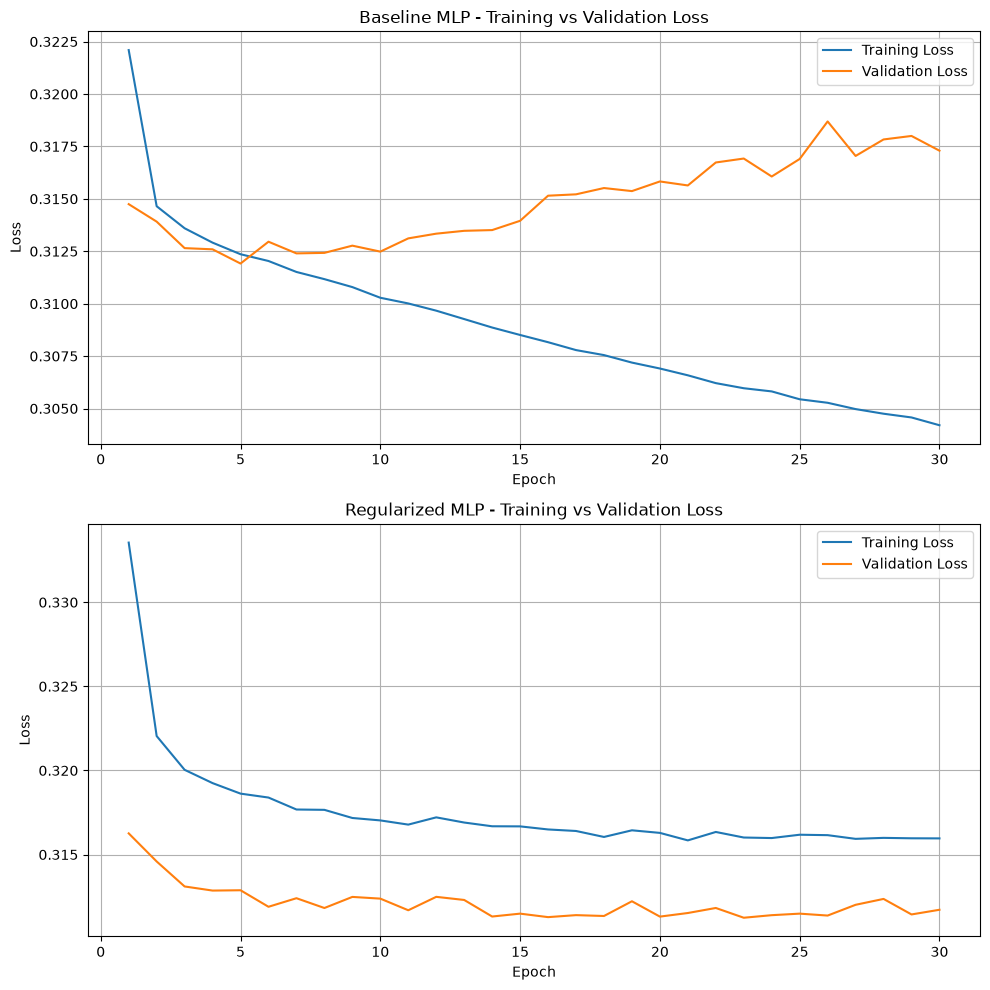

In [95]:
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 10)
)

# Baseline MLP
axes[0].plot(
    epochs,
    baseline_train_losses,
    label="Training Loss"
)

axes[0].plot(
    epochs,
    baseline_val_losses,
    label="Validation Loss"
)

axes[0].set_title(
    "Baseline MLP - Training vs Validation Loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)


# Regularized MLP
axes[1].plot(
    epochs,
    regularized_train_losses,
    label="Training Loss"
)

axes[1].plot(
    epochs,
    regularized_val_losses,
    label="Validation Loss"
)

axes[1].set_title(
    "Regularized MLP - Training vs Validation Loss"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [96]:
baseline_best_val = min(baseline_val_losses)
regularized_best_val = min(regularized_val_losses)

baseline_best_epoch = (
    baseline_val_losses.index(baseline_best_val) + 1
)

regularized_best_epoch = (
    regularized_val_losses.index(regularized_best_val) + 1
)

print("========== DAY 13 MODEL COMPARISON ==========")

print(
    f"Baseline Best Validation Loss: "
    f"{baseline_best_val:.4f}"
)

print(
    f"Baseline Best Epoch: "
    f"{baseline_best_epoch}"
)

print()

print(
    f"Regularized Best Validation Loss: "
    f"{regularized_best_val:.4f}"
)

print(
    f"Regularized Best Epoch: "
    f"{regularized_best_epoch}"
)

print()

print(
    f"Baseline Final Training Loss: "
    f"{baseline_train_losses[-1]:.4f}"
)

print(
    f"Baseline Final Validation Loss: "
    f"{baseline_val_losses[-1]:.4f}"
)

print()

print(
    f"Regularized Final Training Loss: "
    f"{regularized_train_losses[-1]:.4f}"
)

print(
    f"Regularized Final Validation Loss: "
    f"{regularized_val_losses[-1]:.4f}"
)

========== DAY 13 MODEL COMPARISON ==========
Baseline Best Validation Loss: 0.3119
Baseline Best Epoch: 5

Regularized Best Validation Loss: 0.3112
Regularized Best Epoch: 23

Baseline Final Training Loss: 0.3042
Baseline Final Validation Loss: 0.3173

Regularized Final Training Loss: 0.3160
Regularized Final Validation Loss: 0.3117


## Dropout as an Implicit Ensemble

Dropout can be interpreted as training many different smaller subnetworks.

During each training step, a different random set of neurons is deactivated. Therefore, different subnetworks are effectively trained while sharing the same model parameters.

Because the network cannot depend on a fixed group of neurons, it is encouraged to learn features that remain useful across different subnetworks.

For this reason, Dropout can be viewed as an implicit ensemble of smaller neural networks. This behavior helps reduce neuron co-adaptation and can improve the model's ability to generalize to unseen data.

## Day 13 Conclusion

The Day 12 baseline MLP was upgraded with Batch Normalization and Dropout to create a regularized neural network.

Both the baseline MLP and RegularizedMLP were trained for 30 epochs using the same PyTorch DataLoaders, CrossEntropyLoss, and Adam optimizer. Training and validation losses were tracked throughout the experiment.

The baseline and regularized models were compared using their training and validation loss curves, best validation loss, final validation loss, and training-validation loss gap.

Batch Normalization helps stabilize the intermediate activations using mini-batch statistics and learnable gamma and beta parameters. Dropout randomly deactivates neurons during training and uses inverted scaling to preserve the expected activation magnitude.

The observed loss curves and validation results are used to determine whether the regularized model reduced overfitting and improved generalization. The conclusion is based on the actual experimental results rather than assuming that regularization will always produce better performance.